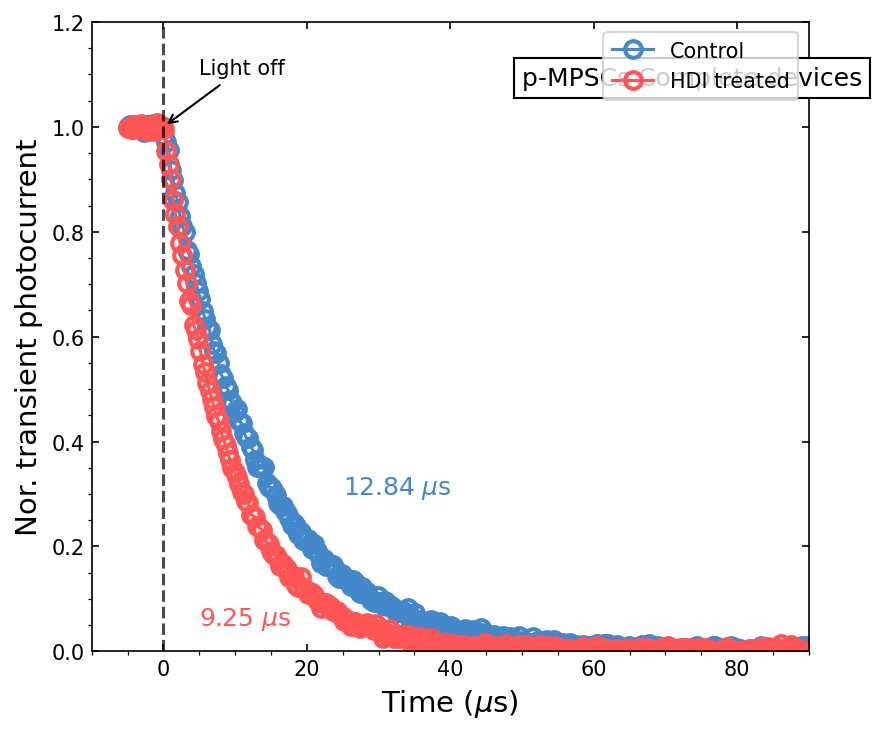

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
time = np.linspace(-5, 90, 300)

def decay(t, t1):
    # Normalized decay
    y = np.zeros_like(t)
    # t<0 = 1.0
    y[t<0] = 1.0
    # t>0 = exp(-t/t1)
    y[t>=0] = np.exp(-t[t>=0]/t1)

    # Add convolution/rise time simulation (optional, but image is sharp drop)
    # Add noise
    y += np.random.normal(0, 0.005, len(t))
    return y

# 1. HDI Treated (Red) - Fast (9.25 us)
y_hdi = decay(time, 9.25)

# 2. Control (Blue) - Slow (12.84 us)
y_ctrl = decay(time, 12.84)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Plots
ax.plot(time, y_ctrl, 'o-', color='#4488CC', mfc='none', markersize=8, mew=2, label='Control')
ax.plot(time, y_hdi, 'o-', color='#FF5555', mfc='none', markersize=8, mew=2, label='HDI treated')

# Dashed line
ax.axvline(0, color='black', linestyle='--', alpha=0.7)
ax.annotate('Light off', xy=(0, 1.0), xytext=(5, 1.1), arrowprops=dict(arrowstyle='->'))

# Labels
ax.text(5, 0.05, r'9.25 $\mu$s', color='#FF5555', fontsize=12)
ax.text(25, 0.3, r'12.84 $\mu$s', color='#4488CC', fontsize=12)

# Legend
ax.legend(frameon=True, loc='upper right', fontsize=10)
ax.text(0.6, 0.9, 'p-MPSCs Complete devices', transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))

# Styling
ax.set_xlabel(r'Time ($\mu$s)', fontsize=14)
ax.set_ylabel('Nor. transient photocurrent', fontsize=14)
ax.set_ylim(0, 1.2)
ax.set_xlim(-10, 90)

# Ticks
ax.minorticks_on()
ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()
